In [12]:
import pandas as pd
df = pd.read_csv("risk_model_dataset_v1.csv")
df.head()


,credit_score,dpd_12m,dpd_24m,active_loans_count,total_outstanding_inr,monthly_income,employment_type,employer_tier,job_tenure_years,requested_amount,...,inconsistency_score,consent_confidence,prior_applications_count,prior_rejections_count,days_since_last_app,last_outcome_encoded,prior_risk_band_encoded,prior_loan_performance_encoded,application_velocity_30d,default
0,603,1,3,1,770577,92496,3,3,1.328886,882031,...,0.839254,0.957697,0,0,128,4,2,1,0,1
1,627,3,4,2,1113041,115800,1,3,1.127920,819126,...,0.078835,0.635136,4,0,44,0,1,3,0,0
2,633,1,4,0,330202,30433,1,3,2.878809,255850,...,0.449506,0.965880,2,0,17,0,0,3,0,1
3,565,0,3,4,272427,62194,3,2,1.187678,377988,...,0.321666,0.725905,1,1,51,1,3,2,1,0
4,679,0,0,2,1078719,88706,1,1,0.500000,661599,...,0.065347,0.602421,3,0,98,2,4,1,1,0


In [13]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

Shape: (9266, 37)

Columns:
 ['credit_score', 'dpd_12m', 'dpd_24m', 'active_loans_count', 'total_outstanding_inr', 'monthly_income', 'employment_type', 'employer_tier', 'job_tenure_years', 'requested_amount', 'loan_to_income_ratio', 'preferred_tenure_months', 'loan_purpose_encoded', 'existing_emi_monthly', 'total_obligations', 'foir_ratio', 'debt_to_income', 'geo_risk_score', 'ip_risk_score', 'device_risk_score', 'liveness_score', 'age_consistency_score', 'face_confidence_score', 'avg_response_latency_ms', 'hesitation_count', 'question_retry_count', 'extraction_confidence_avg', 'inconsistency_score', 'consent_confidence', 'prior_applications_count', 'prior_rejections_count', 'days_since_last_app', 'last_outcome_encoded', 'prior_risk_band_encoded', 'prior_loan_performance_encoded', 'application_velocity_30d', 'default']


In [14]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 credit_score                      0
dpd_12m                           0
dpd_24m                           0
active_loans_count                0
total_outstanding_inr             0
monthly_income                    0
employment_type                   0
employer_tier                     0
job_tenure_years                  0
requested_amount                  0
loan_to_income_ratio              0
preferred_tenure_months           0
loan_purpose_encoded              0
existing_emi_monthly              0
total_obligations                 0
foir_ratio                        0
debt_to_income                    0
geo_risk_score                    0
ip_risk_score                     0
device_risk_score                 0
liveness_score                    0
age_consistency_score             0
face_confidence_score             0
avg_response_latency_ms           0
hesitation_count                  0
question_retry_count              0
extraction_confidence_avg         0
inconsiste

In [15]:
print("\nTarget Distribution:\n", df["default"].value_counts(normalize=True))


Target Distribution:
 default
0    0.714332
1    0.285668
Name: proportion, dtype: float64


In [16]:
print(df.describe())

       credit_score      dpd_12m      dpd_24m  active_loans_count  \
count   9266.000000  9266.000000  9266.000000         9266.000000   
mean     680.848262     1.206670     2.693827            1.998921   
std       79.994848     1.108142     1.652302            1.411234   
min      384.000000     0.000000     0.000000            0.000000   
25%      628.000000     0.000000     1.000000            1.000000   
50%      681.000000     1.000000     2.000000            2.000000   
75%      734.000000     2.000000     4.000000            3.000000   
max      900.000000     8.000000    11.000000            8.000000   

       total_outstanding_inr  monthly_income  employment_type  employer_tier  \
count           9.266000e+03     9266.000000      9266.000000    9266.000000   
mean            6.262975e+05    67056.135873         1.448629       2.247248   
std             3.301164e+05    30225.975017         0.672652       1.043705   
min             5.008600e+04    15017.000000         1.000

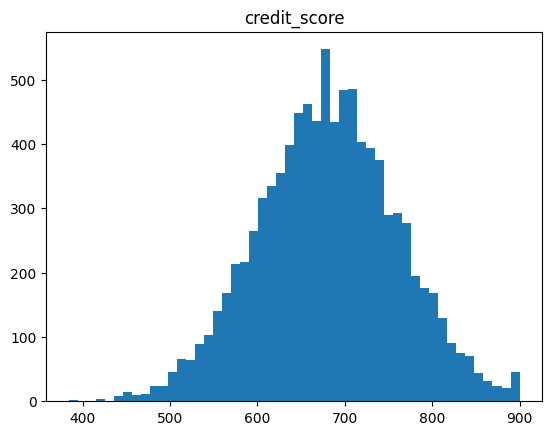

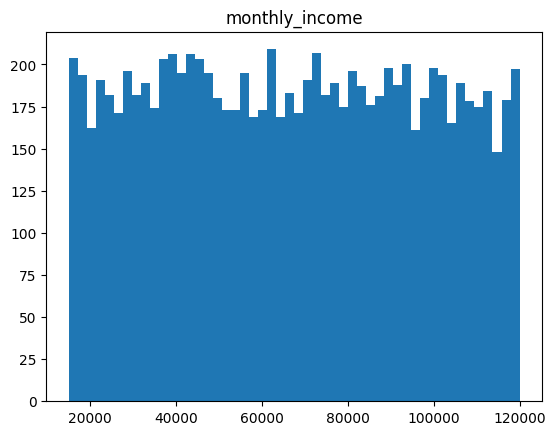

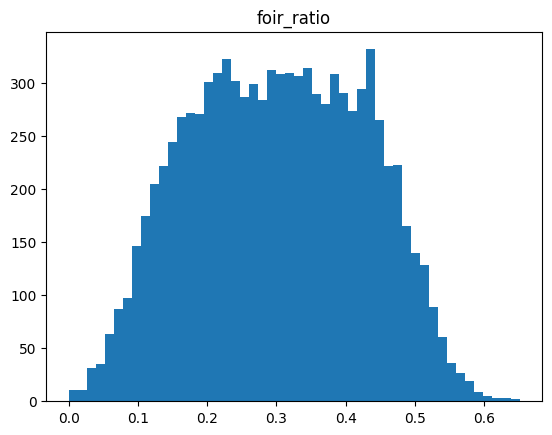

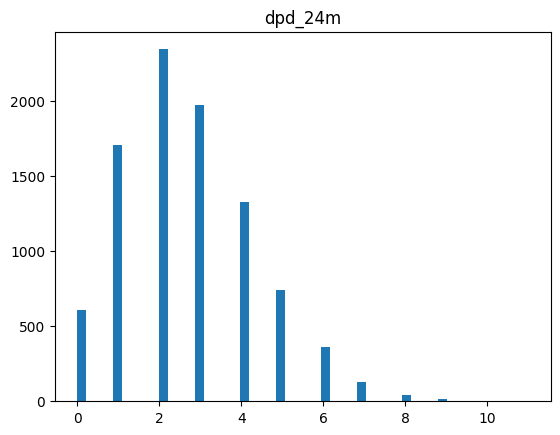

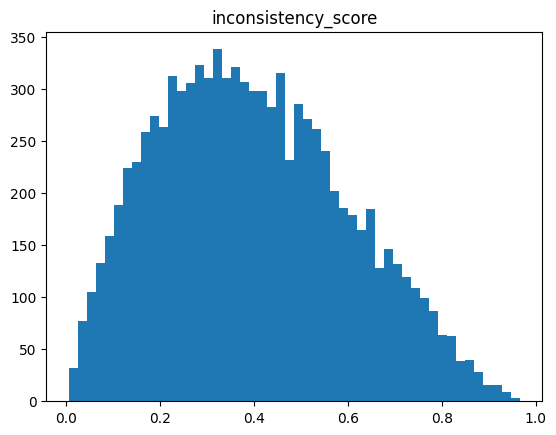

In [17]:
import matplotlib.pyplot as plt

features_to_plot = [
    "credit_score",
    "monthly_income",
    "foir_ratio",
    "dpd_24m",
    "inconsistency_score"
]

for col in features_to_plot:
    plt.hist(df[col], bins=50)
    plt.title(col)
    plt.show()

In [18]:
corr = df.corr()["default"].sort_values(ascending=False)
print(corr)

default                           1.000000
dpd_24m                           0.177340
inconsistency_score               0.116665
dpd_12m                           0.108005
foir_ratio                        0.091902
total_obligations                 0.049804
existing_emi_monthly              0.049804
application_velocity_30d          0.047118
loan_purpose_encoded              0.024501
job_tenure_years                  0.022534
device_risk_score                 0.015595
prior_loan_performance_encoded    0.013687
age_consistency_score             0.009330
extraction_confidence_avg         0.009161
preferred_tenure_months           0.008743
ip_risk_score                     0.007306
avg_response_latency_ms           0.005212
liveness_score                    0.002496
loan_to_income_ratio              0.001846
last_outcome_encoded              0.001666
prior_applications_count          0.000265
prior_rejections_count           -0.001249
hesitation_count                 -0.002505
requested_a

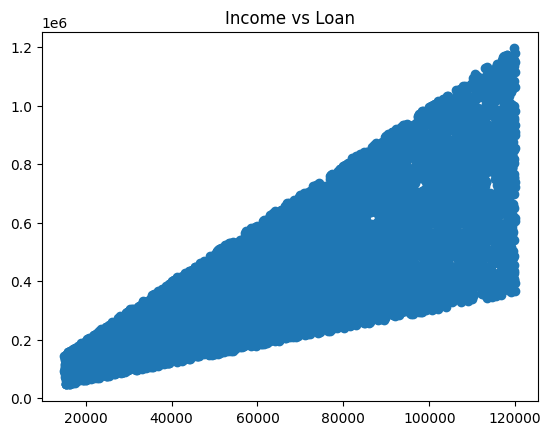

In [19]:
plt.scatter(df["monthly_income"], df["requested_amount"])
plt.title("Income vs Loan")
plt.show()

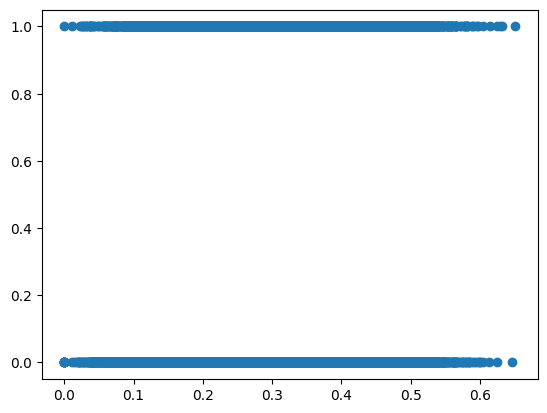

In [20]:
plt.scatter(df["foir_ratio"], df["default"])
plt.show()

In [ ]:
#model training lightgbm and xgboost to select best
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import lightgbm as lgb
import xgboost as xgb

# -----------------------------
# 1. Load Dataset
# -----------------------------
df = pd.read_csv("risk_model_dataset_v1.csv")

X = df.drop("default", axis=1)
y = df["default"]

# -----------------------------
# 2. Train / Val / Test Split
# -----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

# -----------------------------
# 3. KS Statistic Function
# -----------------------------
def ks_stat(y_true, y_pred):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    ks = max(tpr - fpr)
    return ks

# -----------------------------
# 4. LightGBM (Champion)
# -----------------------------
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    random_state=42
)

lgb_model.fit(X_train, y_train)

# Predictions
lgb_pred = lgb_model.predict_proba(X_test)[:, 1]

# Metrics
lgb_auc = roc_auc_score(y_test, lgb_pred)
lgb_gini = 2 * lgb_auc - 1
lgb_ks = ks_stat(y_test, lgb_pred)

print("\n--- LightGBM ---")
print("AUC:", lgb_auc)
print("Gini:", lgb_gini)
print("KS:", lgb_ks)

# -----------------------------
# 5. XGBoost (Challenger)
# -----------------------------
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Predictions
xgb_pred = xgb_model.predict_proba(X_test)[:, 1]

# Metrics
xgb_auc = roc_auc_score(y_test, xgb_pred)
xgb_gini = 2 * xgb_auc - 1
xgb_ks = ks_stat(y_test, xgb_pred)

print("\n--- XGBoost ---")
print("AUC:", xgb_auc)
print("Gini:", xgb_gini)
print("KS:", xgb_ks)

# -----------------------------
# 6. Model Comparison
# -----------------------------
print("\n=== MODEL COMPARISON ===")
print(f"LightGBM  → AUC: {lgb_auc:.4f}, KS: {lgb_ks:.4f}")
print(f"XGBoost   → AUC: {xgb_auc:.4f}, KS: {xgb_ks:.4f}")

# -----------------------------
# 7. Select Best Model
# -----------------------------
if lgb_auc > xgb_auc:
    best_model = "LightGBM"
else:
    best_model = "XGBoost"

print("\nBest Model:", best_model)

Train: (6486, 36)
Val: (1390, 36)
Test: (1390, 36)
[LightGBM] [Info] Number of positive: 1853, number of negative: 4633
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014548 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5457
[LightGBM] [Info] Number of data points in the train set: 6486, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.285692 -> initscore=-0.916399
[LightGBM] [Info] Start training from score -0.916399

--- LightGBM ---
AUC: 0.7005638969004695
Gini: 0.401127793800939
KS: 0.30347698372232834


c:\code\tensorxkyc\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:06:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost ---
AUC: 0.6960156866326248
Gini: 0.3920313732652496
KS: 0.32510698313889924

=== MODEL COMPARISON ===
LightGBM  → AUC: 0.7006, KS: 0.3035
XGBoost   → AUC: 0.6960, KS: 0.3251

Best Model: LightGBM


In [22]:
# Combine X and y back before saving
train_df = X_train.copy()
train_df["default"] = y_train

val_df = X_val.copy()
val_df["default"] = y_val

test_df = X_test.copy()
test_df["default"] = y_test

# Save to CSV
train_df.to_csv("train_data.csv", index=False)
val_df.to_csv("validation_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)

print("Files saved successfully!")

Files saved successfully!


In [ ]:
#hyperparameter tuning to select best parameters for lightgbm model
import optuna
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

# -----------------------------
# Objective Function
# -----------------------------
def objective(trial):
    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "verbosity": -1,
        
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
        "max_depth": trial.suggest_int("max_depth", -1, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0)
    }

    model = lgb.LGBMClassifier(**params)

    model.fit(X_train, y_train)

    preds = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds)

    return auc

# -----------------------------
# Run Optimization
# -----------------------------
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("\nBest Trial:")
print(study.best_trial.value)

print("\nBest Params:")
print(study.best_trial.params)

c:\code\tensorxkyc\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-30 18:16:13,251] A new study created in memory with name: no-name-3fcc217e-881f-4569-b23c-bbe9bbf81929
[I 2026-04-30 18:16:14,740] Trial 0 finished with value: 0.7024892129034221 and parameters: {'n_estimators': 432, 'learning_rate': 0.030218741161250062, 'num_leaves': 62, 'max_depth': 10, 'min_child_samples': 36, 'subsample': 0.6522819003335796, 'colsample_bytree': 0.6294369090765018}. Best is trial 0 with value: 0.7024892129034221.
[I 2026-04-30 18:16:15,422] Trial 1 finished with value: 0.6933927923677329 and parameters: {'n_estimators': 353, 'learning_rate': 0.062980850168797, 'num_leaves': 79, 'max_depth': 13, 'min_child_samples': 64, 'subsample': 0.6813618857435187, 'colsample_bytree': 0.7373091921492622}. Best is trial 0 with


Best Trial:
0.723857937552794

Best Params:
{'n_estimators': 232, 'learning_rate': 0.034124117087326336, 'num_leaves': 74, 'max_depth': 2, 'min_child_samples': 70, 'subsample': 0.9482286299037512, 'colsample_bytree': 0.8840206133586528}


In [ ]:
#model training with best parameters of lightgbm
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, roc_curve

# -----------------------------
# 1. Load Data
# -----------------------------
train_df = pd.read_csv("train_data.csv")
val_df = pd.read_csv("validation_data.csv")
test_df = pd.read_csv("test_data.csv")

# Split features & target
X_train = train_df.drop("default", axis=1)
y_train = train_df["default"]

X_val = val_df.drop("default", axis=1)
y_val = val_df["default"]

X_test = test_df.drop("default", axis=1)
y_test = test_df["default"]

# -----------------------------
# 2. Best Parameters (Optuna)
# -----------------------------
best_params = {
    "n_estimators": 232,
    "learning_rate": 0.034124117087326336,
    "num_leaves": 74,
    "max_depth": 2,
    "min_child_samples": 70,
    "subsample": 0.9482286299037512,
    "colsample_bytree": 0.8840206133586528,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "random_state": 42
}

# -----------------------------
# 3. Train Model
# -----------------------------
model = lgb.LGBMClassifier(**best_params)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="auc"
)

# -----------------------------
# 4. Evaluate Model
# -----------------------------
def ks_stat(y_true, y_pred):
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    return max(tpr - fpr)

# Predictions
train_pred = model.predict_proba(X_train)[:, 1]
val_pred = model.predict_proba(X_val)[:, 1]
test_pred = model.predict_proba(X_test)[:, 1]

# Metrics
print("\n--- MODEL PERFORMANCE ---")
print(f"Train AUC: {roc_auc_score(y_train, train_pred):.4f}")
print(f"Val AUC:   {roc_auc_score(y_val, val_pred):.4f}")
print(f"Test AUC:  {roc_auc_score(y_test, test_pred):.4f}")

print(f"\nTest KS:   {ks_stat(y_test, test_pred):.4f}")
print(f"Test Gini: {(2 * roc_auc_score(y_test, test_pred) - 1):.4f}")

# -----------------------------
# 5. Save Model (CRITICAL)
# -----------------------------
model.booster_.save_model("risk_model_v1.lgb")

print("\n✅ Model saved as risk_model_v1.lgb")


--- MODEL PERFORMANCE ---
Train AUC: 0.7493
Val AUC:   0.7231
Test AUC:  0.7338

Test KS:   0.3699
Test Gini: 0.4675

✅ Model saved as risk_model_v1.lgb


In [26]:
from sklearn.calibration import CalibratedClassifierCV
import joblib

# Wrap model
calibrator = CalibratedClassifierCV(model, method='sigmoid')

# Fit on validation set ONLY
calibrator.fit(X_val, y_val)

# Save calibrator
joblib.dump(calibrator, "calibrator.pkl")

print("✅ Calibrator saved")

✅ Calibrator saved


In [27]:
import json

features = list(X_train.columns)

with open("features.json", "w") as f:
    json.dump(features, f, indent=2)

In [31]:
import json

thresholds = {
    "LOW": 0.15,
    "MEDIUM_LOW": 0.25,
    "MEDIUM_HIGH": 0.40,
    "HIGH": 0.50
}

with open("thresholds.json", "w") as f:
    json.dump(thresholds, f, indent=2)

print("✅ thresholds.json updated")

✅ thresholds.json updated


In [30]:
print(np.percentile(test_pred, [10, 25, 50, 75, 90]))

[0.11947639 0.17759332 0.23736056 0.38893815 0.47859409]


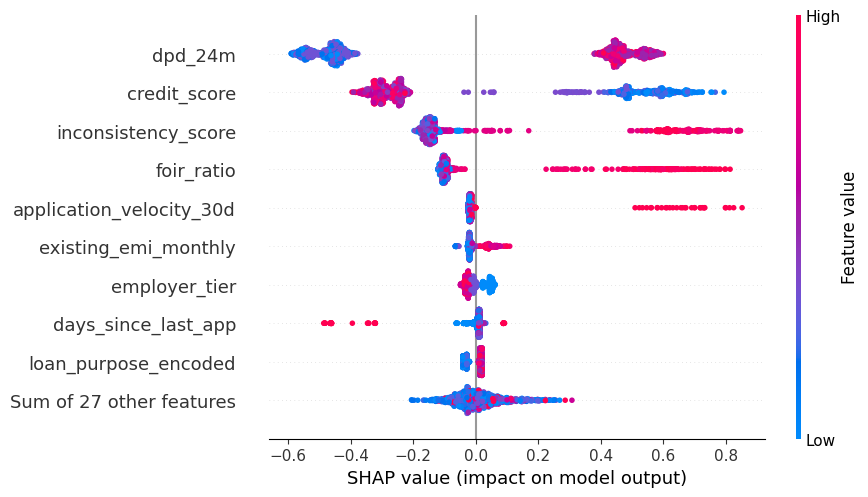

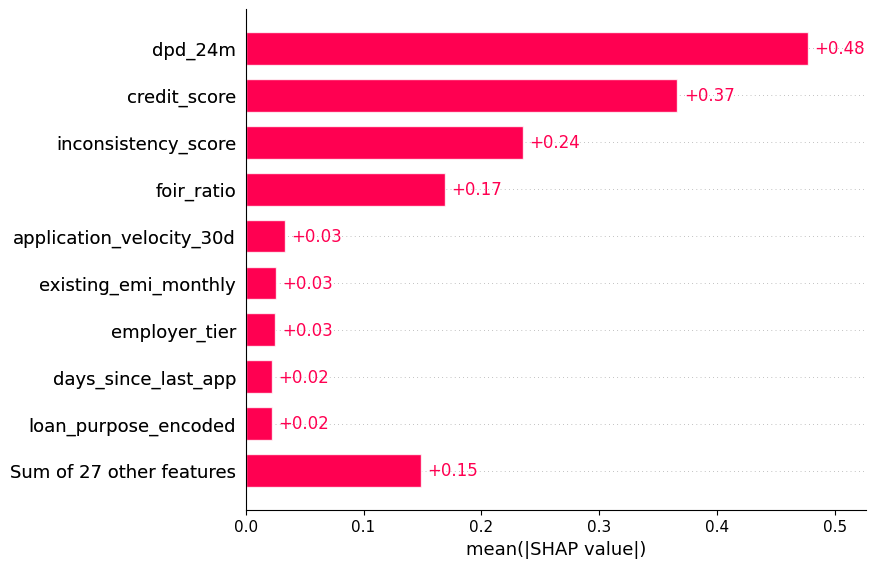

In [33]:
import shap
import pandas as pd
import lightgbm as lgb

# Load data
test_df = pd.read_csv("test_data.csv")
X_test = test_df.drop("default", axis=1)

# Load model
model = lgb.Booster(model_file="risk_model_v1.lgb")

# Create explainer
explainer = shap.Explainer(model)

# Compute SHAP values
shap_values = explainer(X_test)

# -----------------------------
# 1. Summary Plot (Beeswarm)
# -----------------------------
shap.plots.beeswarm(shap_values)

# -----------------------------
# 2. Bar Plot (Feature Importance)
# -----------------------------
shap.plots.bar(shap_values)